# Concentration definitions comparison — fid.h5

Compares the three concentration definitions `ProcessH5` can save (see
`jsm_processh5.py`) for the fiducial Bolshoi-replica run (`fid.h5`):

- **measured** — `c_measured_fixed_COM`, read straight off the simulated halo
- **ludlow** — `ludlow_c`, the Ludlow et al. (2016) mass-concentration relation (built on the Zhao et al. 2009 mass-assembly-history formalism)
- **host** — `host_c`, the analytic host concentration (labeled "zhao" below)

Reads from `data/bolshoi_rep/fid_concentration_comparison_z0.csv`, a
pre-built table holding all three `logc` definitions side by side
(`log_c_measured`, `log_c_ludlow`, `log_c_zhao`) plus the shared,
conctype-independent z0 columns (`logMvir`, `log1pz50`, `logNsub`,
`logfsub`, ...). That table is built once by
`src/bolshoi_rep/concentration_test/build_concentration_comparison_z0.py`,
which runs `ProcessH5` three times on the raw `fid.h5` (~360MB, 1517 trees)
so this notebook doesn't have to re-process the h5 file on every run --
re-run that script if `fid.h5` changes.

1. `log(1+z50)` x `logc` space — 2D `sns.kdeplot` contours, all three models overlaid
2. `logc` alone — 1D `sns.kdeplot` density ("histogram") per model, overlaid
3. Corner plot of all three models across `logMvir`, `log1pz50`, `logc`, `logNsub`, `logfsub`

Note: `log1pz50` doesn't depend on `conctype`, so only `logc` (and where it lands
in the panels) actually differs between the three colors.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath("../../../SatGen/mcmc/src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import jsm_stats

In [2]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')

double_textwidth = 7.0  # inches
single_textwidth = 3.5  # inches
levelz = [1 - 0.99, 1 - 0.95, 1 - 0.68]  # contour levels

colors = {"measured": "steelblue", "ludlow": "darkorange", "host": "seagreen"}

## Load the pre-built concentration-comparison table

Reads `fid_concentration_comparison_z0.csv` (see the intro cell for how
it's built) and reshapes it into a tidy long-format table with a `model`
column, so `sns.kdeplot(..., hue="model")` overlays all three directly.

In [ ]:
datadir = "../../data/bolshoi_rep"
fname = "fid.h5"
master_fname = "fid_concentration_comparison_z0.csv"

master = pd.read_csv(f"{datadir}/{master_fname}")

conctypes = [("measured", "measured"), ("ludlow", "ludlow"), ("host", "zhao")]

frames = []
for label, csv_suf in conctypes:
    df = master[["tree_index", "log1pz50"]].copy()
    df["logc"] = master[f"log_c_{csv_suf}"]
    df["model"] = label
    frames.append(df)

matched = pd.concat(frames, ignore_index=True)
matched.head()

## Figure 1 — log(1+z50) x logc

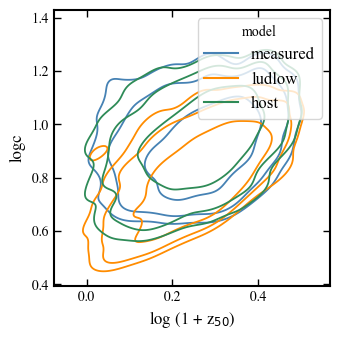

In [4]:
model_order = ["measured", "ludlow", "host"]
model_labels = {"measured": "measured", "ludlow": "ludlow", "host": "zhao"}

fig, ax = plt.subplots(figsize=(single_textwidth, single_textwidth))

handles = []
for model in model_order:
    sub = matched[matched["model"] == model]

    sns.kdeplot(x=sub["log1pz50"], y=sub["logc"], levels=levelz, fill=False,
                linewidths=1.3, color=colors[model], ax=ax)

    rho = jsm_stats.correlation(sub["log1pz50"].values, sub["logc"].values)
    handles.append(plt.Line2D([0], [0], color=colors[model], lw=1.8,
                               label=f"{model_labels[model]} ($\\rho$={rho:.2f})"))

ax.set_xlabel("log (1 + z$_{50}$)", fontsize=12, fontfamily="Times")
ax.set_ylabel("logc", fontsize=12, fontfamily="Times")
ax.tick_params(labelsize=10)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("Times")

ax.legend(handles=handles, fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

# fig.savefig("z50_vs_logc_fid.pdf", dpi=300, bbox_inches="tight")


## Figure 2 — logc, 1D

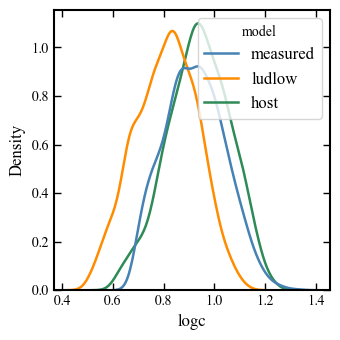

In [5]:
fig, ax = plt.subplots(figsize=(single_textwidth, single_textwidth))

sns.kdeplot(data=matched, x="logc", hue="model", palette=colors, fill=False, lw=1.8, ax=ax)

ax.set_xlabel("logc", fontsize=12, fontfamily="Times")
ax.tick_params(labelsize=10)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("Times")

plt.tight_layout()
plt.show()

# fig.savefig("logc_hist_fid.pdf", dpi=300, bbox_inches="tight")

## Corner plot: measured vs ludlow vs zhao

Same panel layout as `bolshoi_rep.ipynb`'s `plot_corner_with_corr` (diagonal =
1D KDE marginals, lower triangle = 2D KDE contours + Spearman $\rho$
annotated per model), applied here to the three concentration definitions
from `fid.h5` instead of the five orbit-physics variants.

Reuses the same `master` table loaded above (now keeping the full z0-table
column set -- `logMvir`, `log1pz50`, `logc`, `logNsub`, `logfsub` -- instead
of just `log1pz50`/`logc`) and matches all three concentration definitions
by `tree_index` (inner merge; trivial here since all three come from the
same table, but kept for consistency with `bolshoi_rep.ipynb` and as a
safety net if the table ever gains missing values per column). As noted
above, only `logc` actually depends on `conctype` -- the other columns are
identical across the three -- so only panels involving `logc` should show
separation between models; the rest are a consistency check.

In [ ]:
import itertools


def plot_corner_with_corr(matched, models, keys, paramNames, colors,
                           paramRanges=None, figsize=14):
    """
    Corner comparison between an arbitrary number of models using a matched
    dataframe, with Spearman correlation coefficients annotated in each
    off-diagonal panel.

    models : list of (suffix, label) tuples, e.g. [("fid", "fiducial"), ("DF_up", "DF up")]
    keys   : column base-names to compare, expected in matched as f"{key}_{suffix}"
    paramRanges : list of [lo, hi] per key, or None to auto-range from the data (1st/99th percentile + 5% pad)
    """

    model_colors = dict(zip([m for _, m in models], colors))

    model_chains = {}
    model_rho = {}

    for suffix, model in models:
        cols = [f"{k}_{suffix}" for k in keys]
        chain = matched[cols].copy()
        chain.columns = keys

        mask = ~chain.isna().any(axis=1)
        chain = chain.loc[mask].reset_index(drop=True)

        pair_rho = {}
        for k1, k2 in itertools.combinations(keys, 2):
            pair_rho[(k1, k2)] = jsm_stats.correlation(chain[k1].values, chain[k2].values)

        model_chains[model] = chain
        model_rho[model] = pair_rho

    if paramRanges is None:
        paramRanges = []
        for k in keys:
            allvals = np.concatenate([model_chains[m][k].values for _, m in models])
            allvals = allvals[np.isfinite(allvals)]
            lo, hi = np.nanpercentile(allvals, [1, 99])
            pad = 0.5 * (hi - lo if hi > lo else 1.0)
            paramRanges.append([lo - pad, hi + pad])

    nDim = len(keys)
    fig, axes = plt.subplots(nDim, nDim, figsize=(figsize, figsize))

    for i in range(nDim):
        for j in range(nDim):
            ax = axes[i, j]

            if j > i:
                ax.axis("off")
                continue

            if i == j:
                for _, model in models:
                    chain = model_chains[model]
                    sns.kdeplot(chain[keys[i]], ax=ax, color=model_colors[model], fill=False, lw=1.8)
                ax.set_xlim(paramRanges[i])
                ax.set_yticks([])

            else:
                for _, model in models:
                    chain = model_chains[model]
                    sns.kdeplot(x=chain[keys[j]], y=chain[keys[i]], ax=ax, color=model_colors[model],
                                levels=levelz, fill=False, linewidths=1.3)
                ax.set_xlim(paramRanges[j])
                ax.set_ylim(paramRanges[i])

                pair = (keys[j], keys[i])
                first_model = models[0][1]
                if pair not in model_rho[first_model]:
                    pair = (keys[i], keys[j])

                y0 = 0.92
                for _, model in models:
                    rho = model_rho[model][pair]
                    ax.text(0.6, y0, "$\\rho$=" + f"{rho:.2f}", transform=ax.transAxes, fontsize=8,
                            color=model_colors[model],
                            bbox=dict(boxstyle="round", facecolor="white", alpha=1, edgecolor="k", pad=0.15))
                    y0 -= 0.13

            if i < nDim - 1:
                ax.set_xticklabels([])
                ax.set_xlabel("")
            else:
                ax.set_xlabel(paramNames[j], fontsize=12, fontfamily="Times")

            if j > 0 or i == j:
                ax.set_yticklabels([])
                ax.set_ylabel("")
            else:
                ax.set_ylabel(paramNames[i], fontsize=12, fontfamily="Times")

            ax.tick_params(labelsize=10)
            for label in ax.get_xticklabels() + ax.get_yticklabels():
                label.set_fontfamily("Times")

    handles = [plt.Line2D([0], [0], color=model_colors[model], lw=1.8, label=model) for _, model in models]
    fig.legend(handles=handles, loc="upper right", fontsize=12, frameon=False)

    plt.subplots_adjust(wspace=0.08, hspace=0.08)
    plt.tight_layout()
    return fig

In [ ]:
def add_suffix(df, suf):
    return df.rename(columns={c: f"{c}_{suf}" for c in df.columns if c != "tree_index"})

conc_models = [("measured", "measured"), ("ludlow", "ludlow"), ("host", "zhao")]

conc_dfs = {}
for suf, csv_suf in conc_models:
    df = master[["tree_index", "logMvir", "log1pz50", "logNsub", "logfsub"]].copy()
    df["logc"] = master[f"log_c_{csv_suf}"]
    conc_dfs[suf] = df

conc_frames = [add_suffix(conc_dfs[suf], suf) for suf, _ in conc_models]
conc_matched = conc_frames[0]
for frame in conc_frames[1:]:
    conc_matched = conc_matched.merge(frame, on="tree_index", how="inner")

print(f"{len(conc_matched)} trees matched by tree_index across all 3 concentration models "
      "(of " + ", ".join(f"{len(conc_dfs[suf])} {suf}" for suf, _ in conc_models) + ")")

In [ ]:
conc_keys = ["logMvir", "log1pz50", "logc", "logNsub", "logfsub"]
conc_paramNames = ["logM$_{\\rm vir}$", "log (1 + z$_{50}$)", "logc", "logNsub", "logfsub"]
conc_colors = (colors["measured"], colors["ludlow"], colors["host"])

fig = plot_corner_with_corr(conc_matched, models=conc_models, keys=conc_keys, paramNames=conc_paramNames,
                             colors=conc_colors, figsize=9.0)
# fig.savefig("../../figures/concentration_comparison_fid_corner.pdf", bbox_inches="tight")  # not auto-saving to disk -- left inline only